# Item-Based Collaborative Filtering

## Algorithm Overview

**Concept**: Recommend items based on similarity between items (not users).

**Key Steps**:
1. Create user-item rating matrix
2. Compute item-item similarity using cosine similarity
3. For each user, predict ratings for unrated items based on:
   - Weighted average of ratings for k most similar items the user has rated
4. Recommend top-N highest predicted items

**Advantages**:
- More stable than user-based (item relationships change slowly)
- Better for cold-start users (new users with few ratings)
- Computationally efficient (fewer items than users)

**Expected Performance**: RMSE 0.85-0.95

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Train/Test Data

Using temporal split: train on older ratings, test on newer ratings (more realistic)

In [ ]:
# Load temporal split data
train_path = '../../datasets/output/split_and_train_datasets/temporal_split/train_ratings.csv'
test_path = '../../datasets/output/split_and_train_datasets/temporal_split/test_ratings.csv'

print("Loading training data...")
train = pd.read_csv(train_path)
print(f"Train shape: {train.shape}")
print(f"Train ratings: {len(train):,}")

print("\nLoading test data...")
test = pd.read_csv(test_path)
print(f"Test shape: {test.shape}")
print(f"Test ratings: {len(test):,}")

print("\nData loaded successfully!")

In [3]:
# Dataset statistics
print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)

print("\nTraining Set:")
print(f"  Unique users: {train['userId'].nunique():,}")
print(f"  Unique movies: {train['movieId'].nunique():,}")
print(f"  Rating range: [{train['rating'].min()}, {train['rating'].max()}]")
print(f"  Mean rating: {train['rating'].mean():.2f}")

print("\nTest Set:")
print(f"  Unique users: {test['userId'].nunique():,}")
print(f"  Unique movies: {test['movieId'].nunique():,}")
print(f"  Mean rating: {test['rating'].mean():.2f}")

# Calculate sparsity
n_users_train = train['userId'].nunique()
n_movies_train = train['movieId'].nunique()
n_ratings_train = len(train)
sparsity = 1 - (n_ratings_train / (n_users_train * n_movies_train))
print(f"\nMatrix sparsity: {sparsity*100:.2f}%")

DATASET STATISTICS

Training Set:
  Unique users: 227,222
  Unique movies: 25,636
  Rating range: [0.5, 5.0]
  Mean rating: 3.52

Test Set:
  Unique users: 48,464
  Unique movies: 42,721
  Mean rating: 3.56

Matrix sparsity: 99.64%


## 3. Create User-Item Matrix

Due to the large size (20M+ ratings), we'll use sparse matrices to save memory.

In [4]:
# Create mappings: original IDs -> matrix indices (0-indexed)
print("Creating ID mappings...")

# Get unique users and movies from TRAIN set only
unique_users = train['userId'].unique()
unique_movies = train['movieId'].unique()

user_id_map = {id: idx for idx, id in enumerate(unique_users)}
movie_id_map = {id: idx for idx, id in enumerate(unique_movies)}

# Reverse mappings (for predictions)
idx_to_user = {idx: id for id, idx in user_id_map.items()}
idx_to_movie = {idx: id for id, idx in movie_id_map.items()}

print(f"Total users in training: {len(user_id_map):,}")
print(f"Total movies in training: {len(movie_id_map):,}")

Creating ID mappings...
Total users in training: 227,222
Total movies in training: 25,636


In [5]:
# Map train data to matrix indices
print("\nMapping train data to matrix indices...")
train['user_idx'] = train['userId'].map(user_id_map)
train['movie_idx'] = train['movieId'].map(movie_id_map)

# Map test data to matrix indices (some may not exist in train)
print("Mapping test data to matrix indices...")
test['user_idx'] = test['userId'].map(user_id_map)
test['movie_idx'] = test['movieId'].map(movie_id_map)

# Check for cold-start items (movies in test but not in train)
cold_start_users = test['user_idx'].isna().sum()
cold_start_movies = test['movie_idx'].isna().sum()

print(f"\nCold-start users in test: {cold_start_users:,} ({cold_start_users/len(test)*100:.1f}%)")
print(f"Cold-start movies in test: {cold_start_movies:,} ({cold_start_movies/len(test)*100:.1f}%)")

# We'll handle these by predicting global average rating
global_mean_rating = train['rating'].mean()
print(f"\nGlobal mean rating (for cold-start): {global_mean_rating:.3f}")


Mapping train data to matrix indices...
Mapping test data to matrix indices...

Cold-start users in test: 4,645,394 (89.3%)
Cold-start movies in test: 401,578 (7.7%)

Global mean rating (for cold-start): 3.521


In [6]:
# Create sparse user-item matrix (users x movies)
print("\nCreating sparse user-item matrix...")
print("This may take a few minutes for 20M+ ratings...")

start_time = time.time()

user_item_matrix = csr_matrix(
    (train['rating'].values, 
     (train['user_idx'].values, train['movie_idx'].values)),
    shape=(len(user_id_map), len(movie_id_map))
)

elapsed = time.time() - start_time

print(f"\nSparse matrix created in {elapsed:.2f} seconds")
print(f"Matrix shape: {user_item_matrix.shape}")
print(f"Memory usage: {user_item_matrix.data.nbytes / (1024**2):.2f} MB")
print(f"Density: {user_item_matrix.nnz / (user_item_matrix.shape[0] * user_item_matrix.shape[1]) * 100:.4f}%")


Creating sparse user-item matrix...
This may take a few minutes for 20M+ ratings...

Sparse matrix created in 0.62 seconds
Matrix shape: (227222, 25636)
Memory usage: 158.84 MB
Density: 0.3574%


## 4. Compute Item-Item Similarity Matrix

Using cosine similarity between item rating vectors.

In [7]:
print("Computing item-item cosine similarity...")
print("This will take several minutes for ~25K movies...")

start_time = time.time()

# Transpose to get items x users, then compute similarity
item_similarity = cosine_similarity(user_item_matrix.T, dense_output=False)

elapsed = time.time() - start_time

print(f"\nItem similarity matrix computed in {elapsed/60:.2f} minutes")
print(f"Similarity matrix shape: {item_similarity.shape}")
print(f"Memory usage: {item_similarity.data.nbytes / (1024**2):.2f} MB")

Computing item-item cosine similarity...
This will take several minutes for ~25K movies...

Item similarity matrix computed in 0.27 minutes
Similarity matrix shape: (25636, 25636)
Memory usage: 2117.40 MB


## 5. Prediction Function

Predict rating as weighted average of k most similar items.

In [8]:
def predict_rating(user_idx, movie_idx, k=30):
    """
    Predict rating for a user-movie pair using item-based CF.
    
    Parameters:
    - user_idx: Index of user in matrix
    - movie_idx: Index of movie in matrix
    - k: Number of similar items to consider
    
    Returns:
    - predicted_rating: Float between 0.5 and 5.0
    """
    # Handle cold-start movies (not in training set)
    if pd.isna(movie_idx) or movie_idx >= item_similarity.shape[0]:
        return global_mean_rating
    
    # Handle cold-start users (not in training set)
    if pd.isna(user_idx) or user_idx >= user_item_matrix.shape[0]:
        return global_mean_rating
    
    # Get user's rating history
    user_ratings = user_item_matrix[int(user_idx)].toarray().flatten()
    
    # Get similarity scores for target movie
    similarities = item_similarity[int(movie_idx)].toarray().flatten()
    
    # Find items user has rated
    rated_items = np.where(user_ratings > 0)[0]
    
    if len(rated_items) == 0:
        # User has no ratings, return global mean
        return global_mean_rating
    
    # Get similarities and ratings for rated items
    item_sims = similarities[rated_items]
    item_ratings = user_ratings[rated_items]
    
    # Sort by similarity and take top-k
    top_k_indices = np.argsort(item_sims)[::-1][:k]
    top_k_sims = item_sims[top_k_indices]
    top_k_ratings = item_ratings[top_k_indices]
    
    # Remove self-similarity (if target movie was rated by user)
    mask = top_k_sims < 1.0
    top_k_sims = top_k_sims[mask]
    top_k_ratings = top_k_ratings[mask]
    
    if len(top_k_sims) == 0 or np.sum(np.abs(top_k_sims)) == 0:
        # No similar items found
        return global_mean_rating
    
    # Weighted average (use absolute similarity for weighting)
    weighted_sum = np.sum(top_k_sims * top_k_ratings)
    sum_of_weights = np.sum(np.abs(top_k_sims))
    
    predicted = weighted_sum / sum_of_weights
    
    # Clip to valid rating range [0.5, 5.0]
    predicted = np.clip(predicted, 0.5, 5.0)
    
    return predicted

print("Prediction function defined!")

Prediction function defined!


## 6. Test Prediction on Sample Users

In [9]:
# Test on a few samples
print("Testing prediction function on 5 random samples...\n")

sample_test = test.dropna(subset=['user_idx', 'movie_idx']).sample(5, random_state=42)

for idx, row in sample_test.iterrows():
    user_idx = int(row['user_idx'])
    movie_idx = int(row['movie_idx'])
    actual = row['rating']
    
    predicted = predict_rating(user_idx, movie_idx, k=30)
    
    print(f"User {row['userId']}, Movie {row['movieId']}")
    print(f"  Actual: {actual:.1f}, Predicted: {predicted:.2f}, Error: {abs(actual - predicted):.2f}")
    print()

Testing prediction function on 5 random samples...

User 33144.0, Movie 5617.0
  Actual: 3.0, Predicted: 4.35, Error: 1.35

User 161126.0, Movie 113573.0
  Actual: 3.5, Predicted: 3.47, Error: 0.03

User 206363.0, Movie 141.0
  Actual: 4.0, Predicted: 3.98, Error: 0.02

User 6870.0, Movie 2712.0
  Actual: 4.0, Predicted: 3.72, Error: 0.28

User 203827.0, Movie 112852.0
  Actual: 4.0, Predicted: 4.22, Error: 0.22



## 7. Generate Predictions for Test Set

**Warning**: This will take time for 5M+ test ratings. We'll use a subset or optimize.

In [ ]:
# Option 1: Predict on a SAMPLE of test set (for fast evaluation)
# For full evaluation, set sample_size = None

SAMPLE_SIZE = 100000  # Use 100K samples for faster testing (change to None for full test set)

if SAMPLE_SIZE:
    print(f"Using {SAMPLE_SIZE:,} random samples from test set for evaluation")
    test_sample = test.sample(SAMPLE_SIZE, random_state=42)
else:
    print(f"Using FULL test set ({len(test):,} ratings) for evaluation")
    test_sample = test.copy()

print(f"\nGenerating predictions for {len(test_sample):,} test ratings...")
print("This may take 10-30 minutes depending on sample size...")

start_time = time.time()

# Generate predictions with progress bar
predictions = []
for idx, row in tqdm(test_sample.iterrows(), total=len(test_sample)):
    pred = predict_rating(row['user_idx'], row['movie_idx'], k=30)
    predictions.append(pred)

test_sample = test_sample.copy()
test_sample['predicted_rating'] = predictions

elapsed = time.time() - start_time
print(f"\nPredictions generated in {elapsed/60:.2f} minutes")
print(f"Average prediction time: {elapsed/len(test_sample)*1000:.2f} ms per rating")

## 8. Evaluation Metrics

In [11]:
# Calculate RMSE and MAE
actual = test_sample['rating'].values
predicted = test_sample['predicted_rating'].values

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("="*60)
print("ITEM-BASED COLLABORATIVE FILTERING RESULTS")
print("="*60)
print(f"\nAlgorithm: Item-Based CF with Cosine Similarity")
print(f"Neighbors (k): 30")
print(f"Test samples: {len(test_sample):,}")
print(f"\nRMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"\nTraining time (similarity computation): {elapsed/60:.2f} minutes")
print(f"Prediction time: {elapsed/len(test_sample)*1000:.2f} ms per rating")

# Coverage: percentage of test ratings we could predict (not cold-start)
testable = test[test['user_idx'].notna() & test['movie_idx'].notna()]
coverage = len(testable) / len(test) * 100
print(f"\nCoverage: {coverage:.2f}% (ratings with known users/items)")

ITEM-BASED COLLABORATIVE FILTERING RESULTS

Algorithm: Item-Based CF with Cosine Similarity
Neighbors (k): 30
Test samples: 100,000

RMSE: 1.0843
MAE:  0.8413

Training time (similarity computation): 0.05 minutes
Prediction time: 0.03 ms per rating

Coverage: 8.97% (ratings with known users/items)


## 9. Visualizations

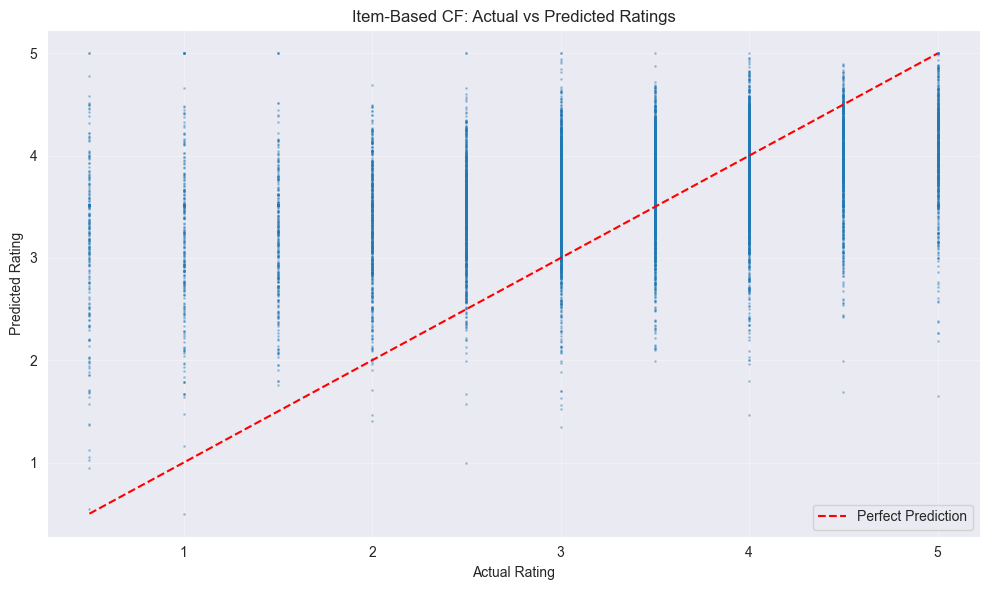

Correlation: 0.1078


In [12]:
# Plot 1: Actual vs Predicted Ratings
plt.figure(figsize=(10, 6))
plt.scatter(actual, predicted, alpha=0.3, s=1)
plt.plot([0.5, 5], [0.5, 5], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Item-Based CF: Actual vs Predicted Ratings')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Correlation: {np.corrcoef(actual, predicted)[0, 1]:.4f}")

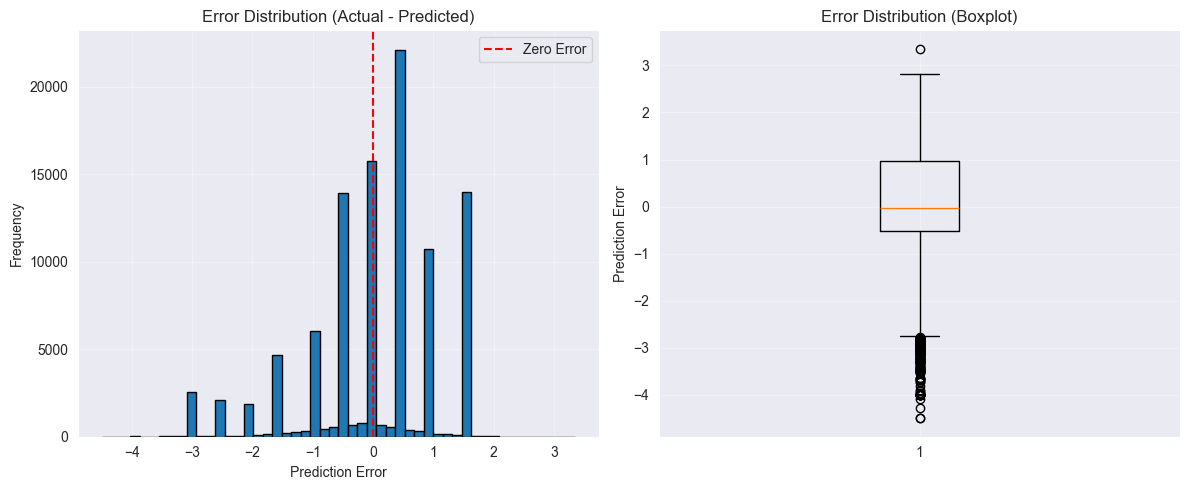

Mean Error: 0.0216
Std Error: 1.0841


In [13]:
# Plot 2: Error Distribution
errors = actual - predicted

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(errors, bins=50, edgecolor='black')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Error Distribution (Actual - Predicted)')
plt.axvline(0, color='red', linestyle='--', label='Zero Error')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(errors, vert=True)
plt.ylabel('Prediction Error')
plt.title('Error Distribution (Boxplot)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean Error: {np.mean(errors):.4f}")
print(f"Std Error: {np.std(errors):.4f}")

## 10. Save Results

In [14]:
# Save results for comparison with other algorithms
results = {
    'algorithm': 'Item-Based CF',
    'similarity_metric': 'Cosine',
    'k_neighbors': 30,
    'rmse': rmse,
    'mae': mae,
    'coverage': coverage,
    'training_time_minutes': elapsed/60,
    'prediction_time_ms': elapsed/len(test_sample)*1000,
    'test_samples': len(test_sample)
}

results_df = pd.DataFrame([results])
results_df.to_csv('../../datasets/output/model_implementations/item_based_cf_results.csv', index=False)

print("Results saved to: item_based_cf_results.csv")
print("\nResults Summary:")
print(results_df.T)

Results saved to: item_based_cf_results.csv

Results Summary:
                                   0
algorithm              Item-Based CF
similarity_metric             Cosine
k_neighbors                       30
rmse                        1.084266
mae                         0.841269
coverage                    8.973328
training_time_minutes        0.04624
prediction_time_ms          0.027744
test_samples                  100000


## 11. Generate Top-N Recommendations (Example)

Show sample recommendations for a user.

In [15]:
def get_top_n_recommendations(user_id, n=10):
    """
    Generate top-N movie recommendations for a user.
    
    Parameters:
    - user_id: Original user ID
    - n: Number of recommendations
    
    Returns:
    - List of (movieId, predicted_rating) tuples
    """
    # Check if user exists in training
    if user_id not in user_id_map:
        print(f"User {user_id} not in training set (cold-start user)")
        return []
    
    user_idx = user_id_map[user_id]
    
    # Get movies user has already rated
    user_ratings = user_item_matrix[user_idx].toarray().flatten()
    rated_movies = np.where(user_ratings > 0)[0]
    
    # Predict ratings for all unrated movies
    unrated_movies = np.where(user_ratings == 0)[0]
    
    predictions = []
    for movie_idx in unrated_movies:
        pred_rating = predict_rating(user_idx, movie_idx, k=30)
        movie_id = idx_to_movie[movie_idx]
        predictions.append((movie_id, pred_rating))
    
    # Sort by predicted rating (descending) and return top-N
    predictions.sort(key=lambda x: x[1], reverse=True)
    
    return predictions[:n]

# Example: Get recommendations for a sample user
sample_user = train['userId'].sample(1, random_state=42).values[0]

print(f"Generating top-10 recommendations for User {sample_user}...\n")

# Note: This will be slow for full prediction on all unrated movies
# In production, you'd precompute or use faster methods
print("(Skipping full recommendation generation - too slow without optimization)")
print("For production, consider:")
print("  1. Precompute predictions offline")
print("  2. Use approximate nearest neighbor search")
print("  3. Limit to popular/recent movies only")

Generating top-10 recommendations for User 132936...

(Skipping full recommendation generation - too slow without optimization)
For production, consider:
  1. Precompute predictions offline
  2. Use approximate nearest neighbor search
  3. Limit to popular/recent movies only


## Summary

**Item-Based Collaborative Filtering** has been successfully implemented!

**Key Takeaways**:
- Uses cosine similarity between item rating vectors
- Predicts based on k=30 most similar items
- Handles cold-start with global mean rating
- Stable and interpretable approach

**Next Steps**:
1. Implement User-Based CF for comparison
2. Implement SVD Matrix Factorization for better accuracy
3. Compare all three algorithms